In [1]:
import os
os.chdir("../")
from src.adecuacion import corrector, ImagenHyper
from src.spacial_bin import binning
from src.labeling import identificar_muestras1, enseñar_muestras,y_prop_label_generation, y_prop_label_generation, combinar_labels, espectros_muestras
from src.rgb import img_rgb, imagen_prediccion, imagen_labelling
import matplotlib.pyplot as plt
import numpy as np
ruta1="""E:/TFM IMAGENES/IMAGENES/"""
dia='30ene2026/'
nombre_muestra='30ene2026_0004_gorliz'
ruta2='/capture/'
white='WHITEREF_'
dark='DARKREF_'
extension='.hdr'

"D:\TFM IMAGENES\IMAGENES\30ene2026\30ene2026_0001_arenas\capture\WHITEREF_30ene2026_0001_arenas.hdr"
ruta_imagen=f"E:/TFM IMAGENES/IMAGENES/{dia}/{nombre_muestra}/capture/{nombre_muestra}{extension}"
ruta_blanco=f"E:/TFM IMAGENES/IMAGENES/{dia}/{nombre_muestra}/capture/WHITEREF_{nombre_muestra}{extension}"
ruta_negro=f"E:/TFM IMAGENES/IMAGENES/{dia}/{nombre_muestra}/capture/DARKREF_{nombre_muestra}{extension}"
imagen_gorliz =corrector(ruta_imagen=ruta_imagen,ruta_blanco=ruta_blanco,ruta_negro=ruta_negro)

<>:17: SyntaxWarning: invalid escape sequence '\T'
<>:17: SyntaxWarning: invalid escape sequence '\T'
C:\Users\unaif\AppData\Local\Temp\ipykernel_10916\1654512450.py:17: SyntaxWarning: invalid escape sequence '\T'
  "D:\TFM IMAGENES\IMAGENES\30ene2026\30ene2026_0001_arenas\capture\WHITEREF_30ene2026_0001_arenas.hdr"
c:\Users\unaif\anaconda3\envs\TFM\Lib\site-packages\spectral\io\envi.py:187: UserWarning: Parameters with non-lowercase names encountered and converted to lowercase. To retain source file parameter name capitalization, set spectral.settings.envi_support_nonlowercase_params to True.
  warnings.warn(msg)


In [2]:
imagen_gorliz=ImagenHyper(imagen_gorliz[0],imagen_gorliz[1] )

In [3]:
gorliz_binned=binning(imagen_gorliz,2)

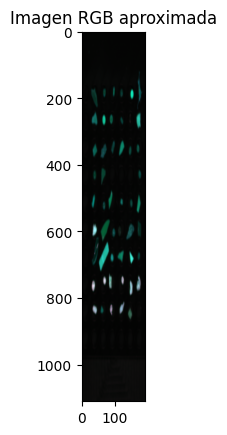

In [4]:
img_rgb(gorliz_binned.img)

In [5]:
from sklearn.cluster import KMeans

from src.adecuacion import img2matrix, matrix2img, ImagenHyper, replace_from_coords

n_clusters = 5
kmeans = KMeans(
    n_clusters=n_clusters,
    random_state=42,
    n_init=10
)
h, w, b = gorliz_binned.shape
labels = kmeans.fit_predict(gorliz_binned.spectra)

cluster_map=matrix2img(labels,h=h, w=w, b=1)

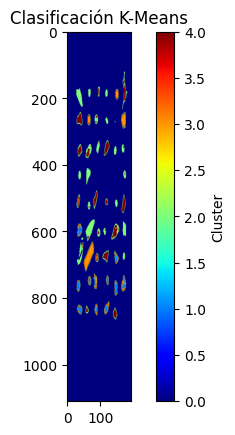

In [6]:

plt.imshow(cluster_map, cmap="jet")
plt.colorbar(label="Cluster")
plt.title("Clasificación K-Means")
plt.show()

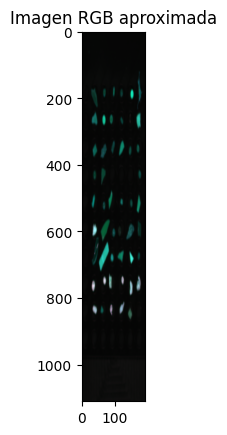

In [7]:
mask = np.argwhere(cluster_map == 0)[:,0:2]
img_rgb(replace_from_coords(gorliz_binned.img, cluster_map,0))

In [8]:
mask=replace_from_coords(gorliz_binned.img, mask, 0).astype(bool)[:,:,0]

In [9]:
gorliz_binned.add_mask(mask=mask)

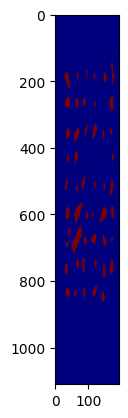

In [10]:
from skimage.morphology import erosion, disk
import matplotlib.pyplot as plt
mask_eroded = erosion(gorliz_binned.mask, disk(1) )

plt.Figure(figsize=(15,15))
plt.imshow(mask_eroded, cmap="jet")

In [11]:
gorliz_binned.add_mask(mask_eroded)

In [12]:
gorliz_binned_sliced=gorliz_binned.slicer("auto")

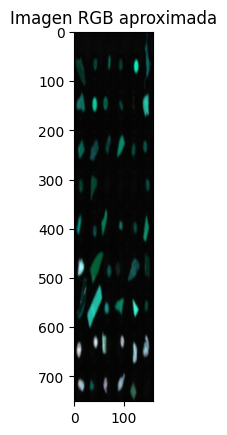

In [13]:
img_rgb(gorliz_binned_sliced.img)

In [14]:
n_plasticos, props=identificar_muestras1(gorliz_binned_sliced)

Plásticos detectados: 54


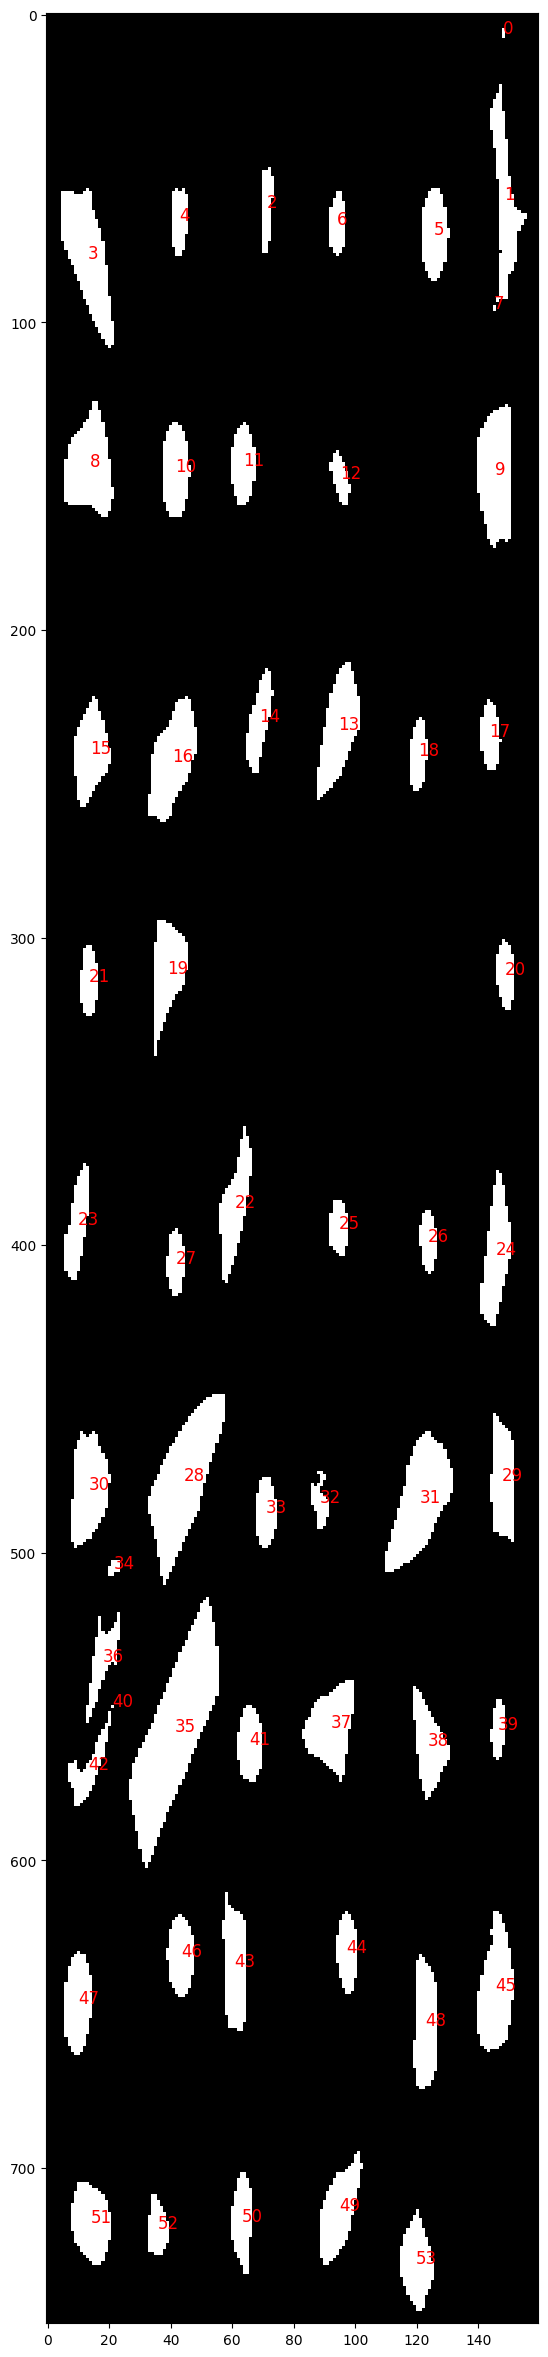

In [15]:
enseñar_muestras(gorliz_binned_sliced.mask, props=props)

In [16]:
espectros_muestras(props=props, img=gorliz_binned_sliced, preprocesado="SNV")

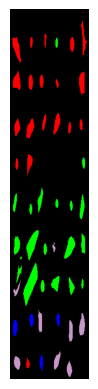

In [17]:
y_prop_label=y_prop_label_generation(54)
y_prop_label[0:6]=1
y_prop_label[6]=2
y_prop_label[7:20]=1
y_prop_label[20]=2
y_prop_label[21]=1
y_prop_label[22:42]=2
y_prop_label[32]=0

y_prop_label[47]=3
y_prop_label[46]=3
y_prop_label[50]=3
y_prop_label[44]=3
y_prop_label[52]=1


y_prop_label
imagen_labelling(y_prop=y_prop_label, props=props, shape=gorliz_binned_sliced.shape
                 )

In [18]:
---

SyntaxError: invalid syntax (1947214667.py, line 1)

In [19]:
os.getcwd()

'c:\\Users\\unaif\\TFM PYTHON\\Repositorio\\TFM'

In [20]:
combinar_labels(gorliz_binned_sliced,y_prop_label, props)

In [ ]:
---

In [21]:
import pickle
with open("DATA/gorliz_binned_sliced.pkl", "wb") as f:
    pickle.dump(gorliz_binned_sliced, f)

True